# Showcase — vessel traffic in the Strait of Hormuz (Sentinel-1 SAR)

The Strait of Hormuz carries roughly a fifth of global oil shipping. Sentinel-1 SAR is the right sensor — calm sea is dark, metal ships return brightly, in any weather. This notebook renders a VV pass with pyramids' `Dataset.plot()`, animates the passes with `DatasetCollection.plot()`, and detects/counts vessels with a CFAR detector.

## What this notebook does

1. **Fetch** six Sentinel-1 VV passes; render one with `Dataset.plot()`.
2. **Animate** them with `DatasetCollection.plot()`.
3. **Detect & count** vessels (CFAR), with a size distribution.

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` and `pyramids-gis[viz]`.

In [1]:
import os, shutil, tempfile, warnings
import numpy as np, matplotlib.pyplot as plt
from loguru import logger
from IPython.display import Image, display
from earthlens import EarthLens
from pyramids.dataset import Dataset, DatasetCollection   # pyramids' own IO + plotting
from scipy import ndimage

warnings.filterwarnings("ignore")
logger.remove()
SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")

def grab(collection, aoi, start, end, bands, scale, reducer="median"):
    """Download one GEE composite over [start, end]; return its GeoTIFF path or None."""
    el = EarthLens(data_source="gee", start=start, end=end, cadence="raw",
        dataset=collection, variables=list(bands), aoi=aoi,
        path=tempfile.mkdtemp(), scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    try:
        p = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001 - needs GEE credentials
        print("download skipped:", exc); return None
    return str(p[0]) if p else None

def read(path):
    return np.asarray(Dataset.read_file(str(path)).read_array(), dtype="float32")

# Sentinel-1 is radar: a single VV backscatter channel (dB), so it is shown in grey -
# there is no "true colour". Bright points are ships; dark fabric is calm water.
AOI = [56.30, 26.50, 56.50, 26.66]; C = "COPERNICUS/S1_GRD"
DATES = ["2024-05-01", "2024-05-13", "2024-05-25", "2024-06-06", "2024-06-18", "2024-06-30"]
pass_dir = tempfile.mkdtemp()
vv, labels = [], []
for d in DATES:
    p = grab(C, AOI, d, d, ["VV"], scale=20, reducer="mean")
    if not p:
        continue
    shutil.copy(p, os.path.join(pass_dir, f"vv_{d.replace('-', '.')}.tif"))
    a = read(p); vv.append(a if a.ndim == 2 else a[0]); labels.append(d)
dc = DatasetCollection.read_multiple_files(pass_dir, date=False) if labels else None   # read the folder
print(f"{len(vv)} passes:", labels)

6 passes: ['2024-05-01', '2024-05-13', '2024-05-25', '2024-06-06', '2024-06-18', '2024-06-30']


## One VV pass — `Dataset.plot()`

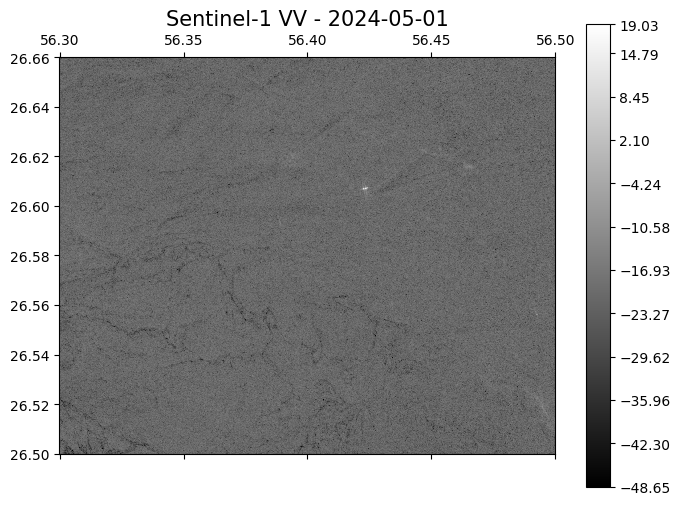

In [2]:
# pyramids renders the SAR backscatter (dB) in grey; bright points are vessels.
if dc:
    dc.iloc(0).plot(band=0, cmap="gray", title=f"Sentinel-1 VV - {labels[0]}")
    plt.show()

## Animated traffic — `DatasetCollection.plot()`

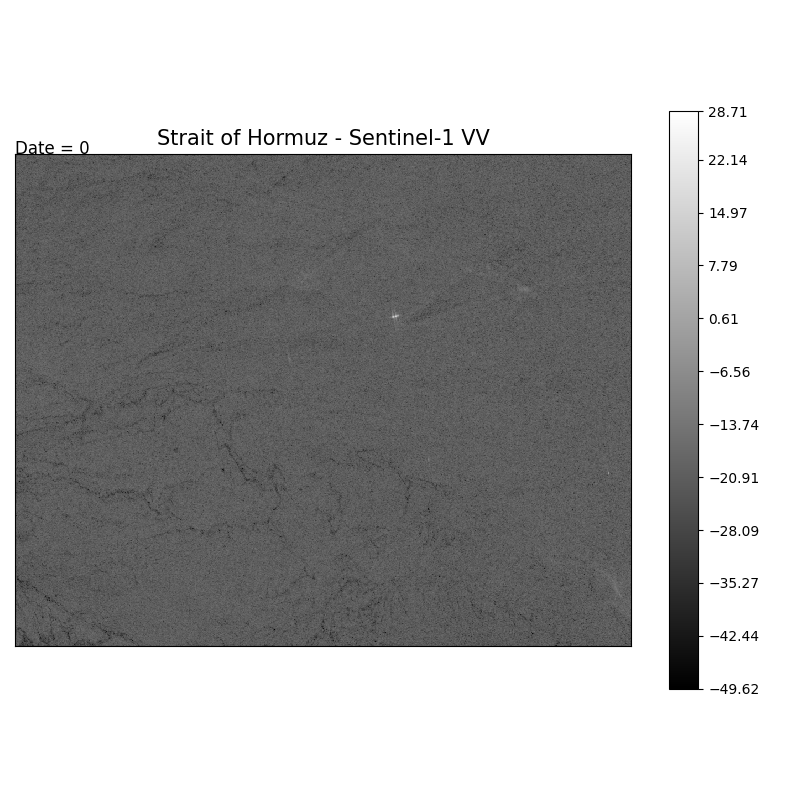

In [3]:
# DatasetCollection animates the VV channel across the six passes (single-band SAR).
if dc:
    gif = os.path.join(tempfile.mkdtemp(), "vv.gif")
    dc.plot(band=0, cmap="gray", title="Strait of Hormuz - Sentinel-1 VV").save_animation(gif, fps=1)
    plt.close("all")
    display(Image(filename=gif))
else:
    print("no passes to animate")

## Detect and count vessels (CFAR)

A temporal-median background marks open water; CFAR flags points far brighter than their local surroundings. The detection still uses **matplotlib** (the red circles are pixel-aligned overlays, which need image pixel coordinates rather than `Dataset.plot`'s geographic axes).

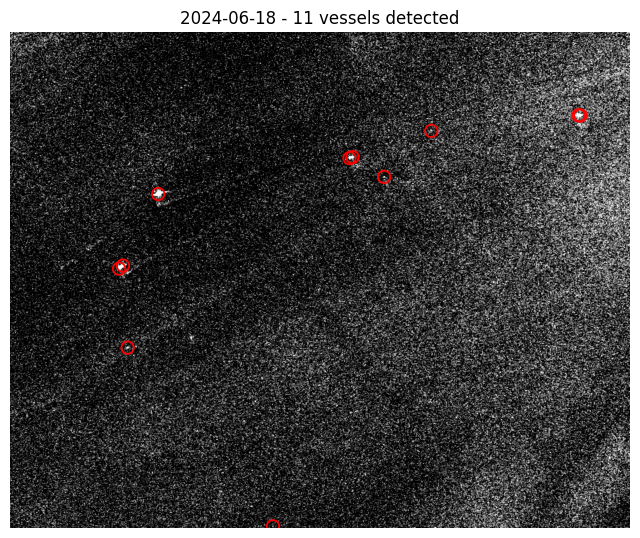

In [4]:
bg = np.nanmedian(np.dstack(vv), axis=2) if vv else None
water = (bg < -16) if bg is not None else None
def detect(a, win=21, k=3.5, lo=2, hi=120):
    z = np.nan_to_num(a, nan=-30); lm = ndimage.uniform_filter(z, size=win)
    ls = np.sqrt(np.maximum(ndimage.uniform_filter(z*z, size=win) - lm*lm, 1e-3))
    lbl, n = ndimage.label(water & (z > -12) & ((z - lm) > k * ls)); out = []
    for i in range(1, n + 1):
        ys, xs = np.where(lbl == i)
        if lo <= ys.size <= hi: out.append((xs.mean(), ys.mean(), ys.size))
    return out
dets = [detect(a) for a in vv] if vv else []; counts = [len(d) for d in dets]
if vv:
    k = int(np.argmax(counts)); a = vv[k]
    lo, hi = np.nanpercentile(a, 40), np.nanpercentile(a, 99.8)
    fig, ax = plt.subplots(figsize=(8, 7)); ax.imshow(np.clip((a-lo)/(hi-lo), 0, 1), cmap="gray")
    if dets[k]:
        xs, ys, _ = zip(*dets[k]); ax.scatter(xs, ys, s=80, facecolors="none", edgecolors="red", linewidths=1.3)
    ax.set_title(f"{labels[k]} - {len(dets[k])} vessels detected"); ax.axis("off"); plt.show()

## Vessels per pass and size distribution

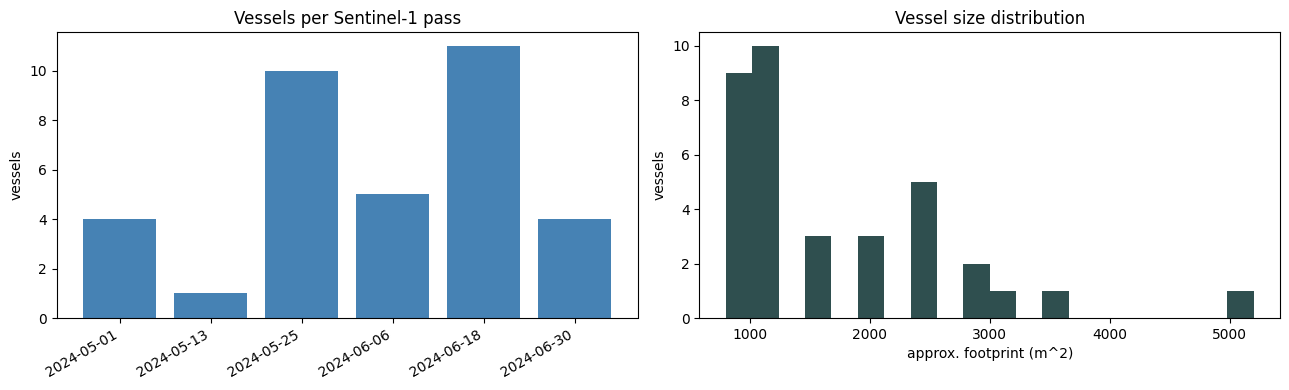

total 35 detections across 6 passes


In [5]:
if vv:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].bar(range(len(counts)), counts, color="steelblue")
    ax[0].set_xticks(range(len(labels))); ax[0].set_xticklabels(labels, rotation=30, ha="right")
    ax[0].set(ylabel="vessels", title="Vessels per Sentinel-1 pass")
    sizes = np.array([s for d in dets for (_, _, s) in d]) * (20 * 20)
    if sizes.size:
        ax[1].hist(sizes, bins=20, color="darkslategray"); ax[1].set(xlabel="approx. footprint (m^2)", ylabel="vessels", title="Vessel size distribution")
    plt.tight_layout(); plt.show()
    print(f"total {sum(counts)} detections across {len(vv)} passes")

## Traffic-density map

Stacking every vessel detection from all six passes onto one grid reveals the busiest part of the lane — the de-facto shipping corridor through the strait.

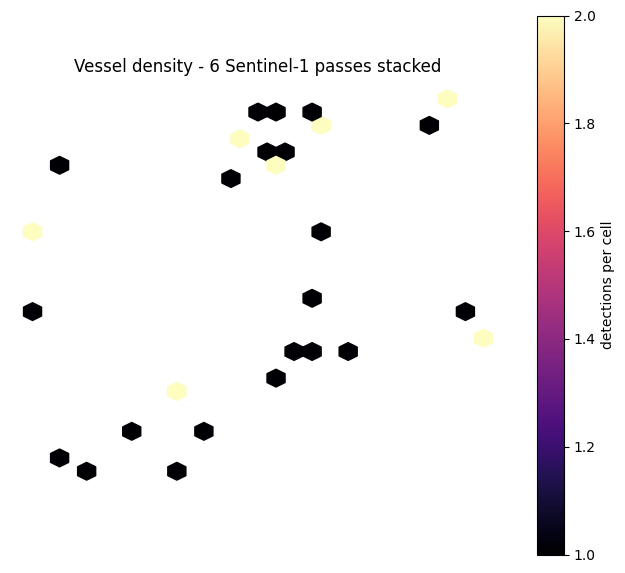

35 detections stacked across 6 passes


In [6]:
# Stack all detections (all passes) into a 2-D density (hexbin) map.
if vv and any(dets):
    allx = [x for d in dets for (x, _, _) in d]
    ally = [y for d in dets for (_, y, _) in d]
    fig, ax = plt.subplots(figsize=(8, 7))
    hb = ax.hexbin(allx, ally, gridsize=25, cmap='magma', mincnt=1)
    ax.invert_yaxis(); ax.set_aspect('equal')
    ax.set_title('Vessel density - 6 Sentinel-1 passes stacked'); ax.axis('off')
    fig.colorbar(hb, ax=ax, label='detections per cell'); plt.show()
    print(f'{sum(len(d) for d in dets)} detections stacked across {len(vv)} passes')
else:
    print('no detections to map')

## Recap

The SAR still and the traffic animation use pyramids' `Dataset.plot` / `DatasetCollection.plot`; the CFAR detection overlay and the size charts use matplotlib.

## Try it yourself

- Tune the CFAR `k`/window, or add more `DATES`.
- See the [GEE backend reference](../../reference/gee/introduction.md).